Assignment Task:
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.


Dataset Description:

The dataset consists of the following variables:

Age: Age in years

KM: Accumulated Kilometers on odometer

FuelType: Fuel Type (Petrol, Diesel, CNG)

HP: Horse Power

Automatic: Automatic ( (Yes=1, No=0)

CC: Cylinder Volume in cubic centimeters

Doors: Number of doors

Weight: Weight in Kilograms

Quarterly_Tax:

Price: Offer Price in EUROs


Tasks:

1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

5.Apply Lasso and Ridge methods on the model.


Interview Questions:

1.What is Normalization & Standardization and how is it helpful?

2.What techniques can be used to address multicollinearity in multiple linear regression?




1 Exploratory data analysis (EDA)

In [62]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [63]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
print(df.head())
print(df.info())
print(df.describe())


   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null  

In [64]:
#checking null values
print(df.isnull().sum())


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


In [65]:
#convert fuel type into numeric
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
print(df.head())

   Price  Age_08_04     KM  HP  Automatic    cc  Doors  Cylinders  Gears  \
0  13500         23  46986  90          0  2000      3          4      5   
1  13750         23  72937  90          0  2000      3          4      5   
2  13950         24  41711  90          0  2000      3          4      5   
3  14950         26  48000  90          0  2000      3          4      5   
4  13750         30  38500  90          0  2000      3          4      5   

   Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
0    1165              True             False  
1    1165              True             False  
2    1165              True             False  
3    1165              True             False  
4    1170              True             False  


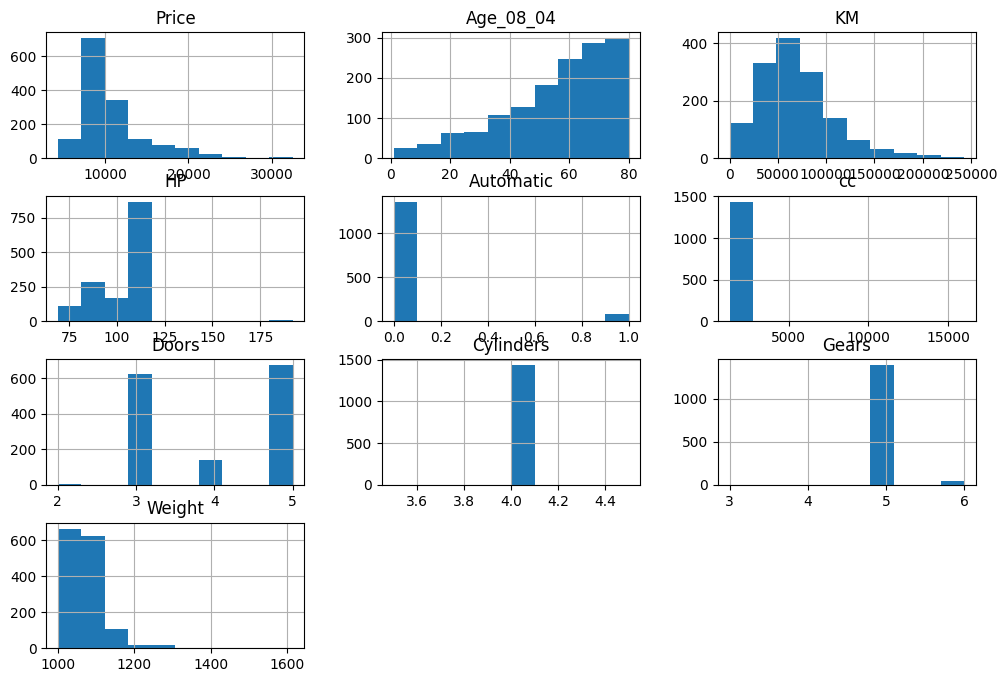

In [66]:
#visualizatoin of data
df.hist(figsize=(12,8))
plt.show()


In [67]:
#correlation
corr = df.corr()
print(corr["Price"].sort_values(ascending=False))


Price               1.000000
Weight              0.581198
HP                  0.314990
Doors               0.185326
cc                  0.126389
Gears               0.063104
Fuel_Type_Diesel    0.054084
Automatic           0.033081
Fuel_Type_Petrol   -0.038516
KM                 -0.569960
Age_08_04          -0.876590
Cylinders                NaN
Name: Price, dtype: float64


2 Split the dataset into training and testing sets

In [68]:
from sklearn.model_selection import train_test_split
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


3 Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [69]:
#first model - uses all variables
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X_train, y_train)

print(model1.coef_)
print(model1.intercept_)


[-1.20830458e+02 -1.62314106e-02  1.40394788e+01  1.48830927e+02
 -3.03721946e-02 -6.03109744e+01 -1.62003744e-12  5.51600710e+02
  2.58849583e+01 -6.85487568e+01  1.37080891e+03]
-14255.385993565254


In [70]:
#second model - uses only important variables
X2 = df[['Age_08_04', 'KM', 'HP', 'Weight']]
y2 = df['Price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)
print(model2.coef_)


[-1.20025405e+02 -2.02325920e-02  2.90521704e+01  1.97690662e+01]


In [71]:
#third model - uses selected varable including cc and Doors
X3 = df[['Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Weight']]
y3 = df['Price']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)
model3 = LinearRegression()
model3.fit(X_train3, y_train3)
print(model3.coef_)


[-1.19956310e+02 -2.01137906e-02  2.92722779e+01 -1.02012240e-01
 -2.23398776e+01  2.02065843e+01]


4 Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [72]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

y_pred = model1.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 Score =", r2)

'''Higher R2 and lower error values indicate better performance.'''


MAE = 990.8872739193926
MSE = 2203043.8231437025
RMSE = 1484.2654153296514
R2 Score = 0.8348888040611082


'Higher R2 and lower error values indicate better performance.'

5 Apply Lasso and Ridge methods on the model.

In [73]:
#lasso regression - it reduces less important feature coefficients to zero
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
print(lasso.coef_)


[-1.20798032e+02 -1.63255341e-02  1.45592200e+01  1.33401454e+02
 -3.23988246e-02 -5.86731609e+01  0.00000000e+00  5.22177477e+02
  2.57219631e+01 -3.23101256e+01  1.36439171e+03]


In [74]:
#ridge regression - reduces coefficient values to handle multicollinearity
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print(ridge.coef_)


[-1.20779659e+02 -1.63240795e-02  1.41418340e+01  1.46907470e+02
 -3.05094386e-02 -5.99057913e+01  0.00000000e+00  5.42272328e+02
  2.58210194e+01 -1.28813072e+02  1.29494983e+03]


In [75]:
"""MLR helps predict Toyota Corolla price uding features like KM HP & Weight.
Lasso and Ridge regression improves model performance."""

'MLR helps predict Toyota Corolla price uding features like KM HP & Weight.\nLasso and Ridge regression improves model performance.'

In [76]:
""" What is Normalization and Standardization?
- Noramliazton scales value between 0 and 1 and is used when features have different ranges.
- Standardization transforms data so mean becomes 0 and stnadard deviation becomes 1. It is used in regression and machine learning algorithms.

What techniques can be used to address multicollinearity in multiple linear regression?
- removes highly corelated values
- use lasso and ridge regression
- use principal component analysis
"""

' What is Normalization and Standardization?\n- Noramliazton scales value between 0 and 1 and is used when features have different ranges.\n- Standardization transforms data so mean becomes 0 and stnadard deviation becomes 1. It is used in regression and machine learning algorithms.\n\nWhat techniques can be used to address multicollinearity in multiple linear regression?\n- removes highly corelated values \n- use lasso and ridge regression\n- use principal component analysis\n'